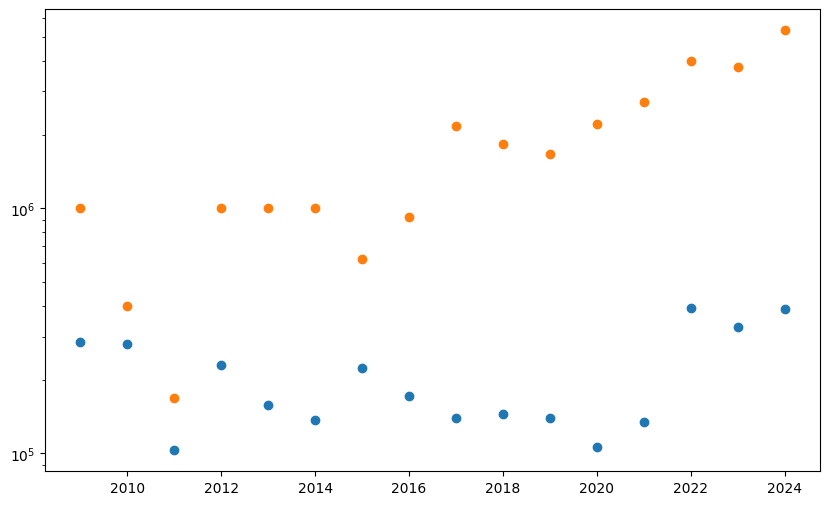

In [2]:
import pandas as  pd
import matplotlib.pyplot as plt

read = pd.read_csv("desplazamientos_colombia_rdc.csv")

fig, ax=plt.subplots(figsize=(10, 6))
ax.scatter(read["Year"], read["Colombia"], label="Colombia")
ax.scatter(read["Year"], read["RDC"], label="RDC")

ax.set_yscale("log")

plt.show()


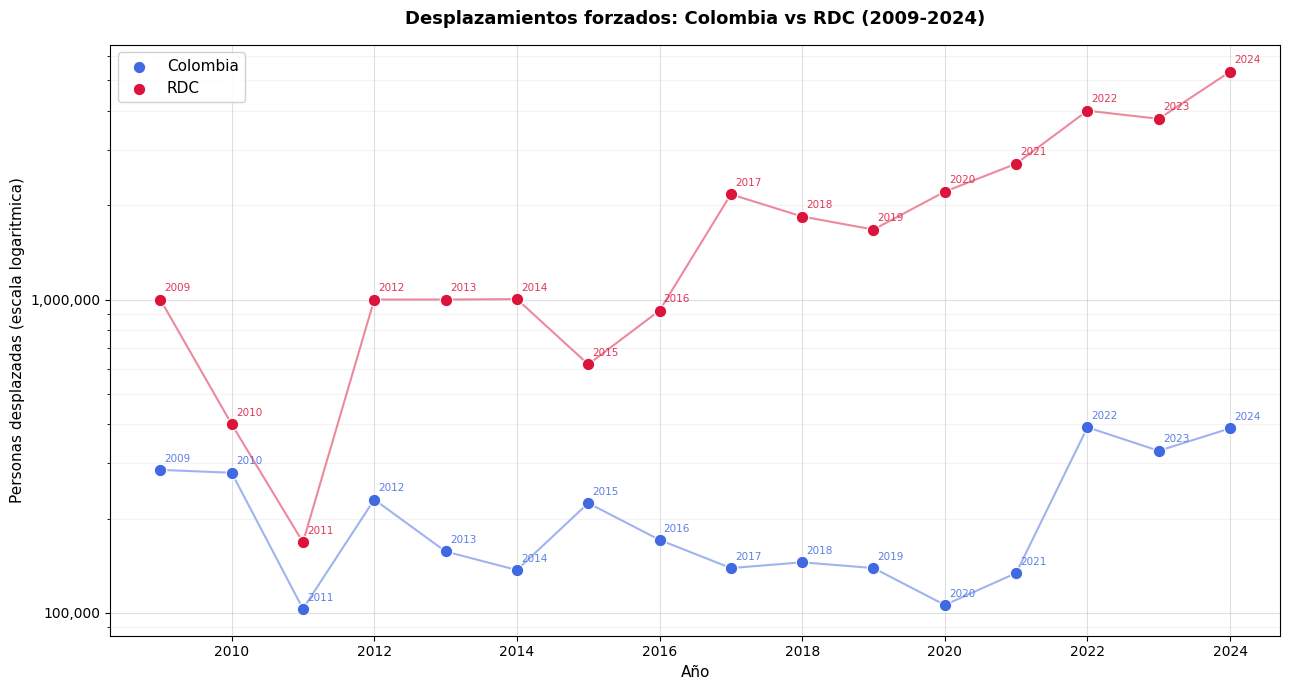

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

read = pd.read_csv("desplazamientos_colombia_rdc.csv")

fig, ax = plt.subplots(figsize=(13, 7))

# Linea + puntos para ver la evolucion temporal
ax.plot(read["Year"], read["Colombia"], color="royalblue", linewidth=1.5, alpha=0.5, zorder=1)
ax.scatter(read["Year"], read["Colombia"], color="royalblue", s=80, label="Colombia", zorder=3, edgecolors="white", linewidths=0.8)

ax.plot(read["Year"], read["RDC"], color="crimson", linewidth=1.5, alpha=0.5, zorder=1)
ax.scatter(read["Year"], read["RDC"], color="crimson", s=80, label="RDC", zorder=3, edgecolors="white", linewidths=0.8)

# Etiqueta del año en cada punto
for _, row in read.iterrows():
    ax.annotate(str(int(row["Year"])), xy=(row["Year"], row["Colombia"]),  xytext=(3, 6), textcoords="offset points", fontsize=7.5, color="royalblue", alpha=0.85)
    ax.annotate(str(int(row["Year"])), xy=(row["Year"], row["RDC"]), xytext=(3, 6), textcoords="offset points", fontsize=7.5, color="crimson", alpha=0.85)

ax.set_yscale("log")

# Eje Y con numeros reales, no notacion cientifica

def formato_miles(x, pos):
    return f"{int(x):,}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formato_miles))

ax.set_title("Desplazamientos forzados: Colombia vs RDC (2009-2024)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Personas desplazadas (escala logaritmica)", fontsize=11)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which="major", alpha=0.4)
ax.grid(True, which="minor", alpha=0.15)
ax.set_xlim(2008.3, 2024.7)

plt.tight_layout()
plt.show()


# LIBRERIAS 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

print("Cargando datos...")


Cargando datos...


In [5]:
df=pd.read_csv("desplazamientos_colombia_rdc.csv")

print("Tabla de datos")
print(df.to_string(index=False))

Tabla de datos
 Year  Colombia     RDC
 2009    286000 1000000
 2010    280000  400000
 2011    103000  168000
 2012    230000 1000000
 2013    157000 1000000
 2014    137000 1003000
 2015    224000  621000
 2016    171000  922000
 2017    139000 2166000
 2018    145000 1840000
 2019    139000 1672000
 2020    106000 2209000
 2021    134000 2712000
 2022    391000 4004000
 2023    329000 3772000
 2024    388000 5333000


In [6]:
list_years = df["Year"].values
años_finales = (list_years - list_years[0]).astype(float)

list_colombia = df["Colombia"].values.astype(float)
list_rdc = df["RDC"].values.astype(float)

print(años_finales)


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


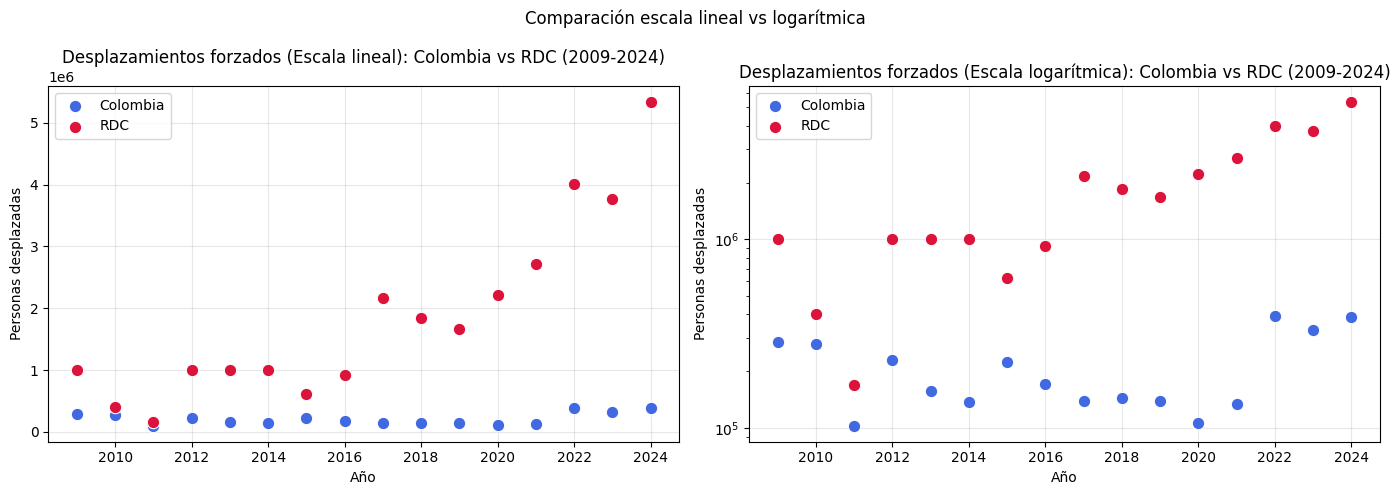

In [7]:
fig,ax=plt.subplots(1, 2, figsize=(14, 5)) 


ax[0].scatter(list_years, list_colombia, color="royalblue", s=80, label="Colombia", zorder=3, edgecolors="white", linewidths=0.8)
ax[0].scatter(list_years, list_rdc, color="crimson", s=80, label="RDC", zorder=3, edgecolors="white", linewidths=0.8)
ax[0].set_title("Desplazamientos forzados (Escala lineal): Colombia vs RDC (2009-2024)")
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Personas desplazadas")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].scatter(list_years, list_colombia, color="royalblue", s=80, label="Colombia", zorder=3, edgecolors="white", linewidths=0.8)
ax[1].scatter(list_years, list_rdc, color="crimson", s=80, label="RDC", zorder=3, edgecolors="white", linewidths=0.8)
ax[1].set_yscale("log")
ax[1].set_title("Desplazamientos forzados (Escala logarítmica): Colombia vs RDC (2009-2024)")
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Personas desplazadas")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.suptitle("Comparación escala lineal vs logarítmica")
plt.tight_layout()
plt.show()

In [8]:
GRADOS_DE_POLINOMIO = {
    1: "Lineal",  # Lineal
    2: "Cuadrático",  # Cuadrático
    3: "Cúbico",  # Cúbico
    4: "Cuartico",  # Cuartico
    5: "Quíntico",  # Quíntico
    6: "Sextico",  # Sextico
    7: "Septico",  # Septico
    8: "Octico",  # Octico
    9: "Nonico",  # Nonico
    10: "Decico"  # Decico
}

def encontrar_modelo(x, y, nombre_pais, grado=10):
    modelos = {}


    #modelos polinomiales del 1 al grado especificado
    for g in range(1, grado + 1):
        coeficientes = np.polyfit(x, y, g)
        y_pred = np.polyval(coeficientes, x)
        r2 = r2_score(y, y_pred)
        clave = f"{GRADOS_DE_POLINOMIO.get(g, f'Grado {g}')} (R²={r2:.4f})"
        modelos[clave] = {"coeficientes": coeficientes, "y_pred": y_pred, "r2": r2, "tipo": "Polinomial", "grado": g}

    #modelo exponencial
    log_y = np.log(y)
    coef_exp = np.polyfit(x, log_y, 1)
    y_pred_exp = np.exp(np.polyval(coef_exp, x))
    r2_exp = r2_score(y, y_pred_exp)
    modelos[f"Exponencial (R²={r2_exp:.4f})"] = {"coeficientes": coef_exp, "y_pred": y_pred_exp, "r2": r2_exp, "tipo": "Exponencial", "grado": None}

    mejor_r2 = max(d["r2"] for d in modelos.values())
    candidatos = [k for k in modelos.values() if k["tipo"] == "Polinomial" and k["r2"] >= 0.95]
    grado_min_95 = min(v["grado"] for v in candidatos) if candidatos else None

    print(f"\n{'='*65}")
    print(f"  COMPARACIÓN DE MODELOS — {nombre_pais.upper()}")
    print(f"{'='*65}")
    print(f"  {'Modelo':<24} {'R²':>8}  {'≥0.95':>6}  Nota")
    print(f"  {'------':<24} {'--':>8}  {'-----':>6}  ----")
    for nombre_m, datos in modelos.items():
        cumple = "✓" if datos['r2'] >= 0.95 else ""
        nota   = ""
        if datos['tipo'] == "Polinomial" and datos['grado'] == grado_min_95:
            nota = " ← ELEGIDO (mín. grado con R²≥0.95)"
        elif datos['r2'] == mejor_r2 and not candidatos:
            nota = " ← MEJOR DISPONIBLE"
        print(f"  {nombre_m:<24} {datos['r2']:>8.4f}  {cumple:>6}  {nota}")

    if grado_min_95:
        print(f"\n  → Grado mínimo con R²≥0.95: {grado_min_95} ({GRADOS_DE_POLINOMIO[grado_min_95]})")
    else:
        print(f"\n  ⚠ Ningún polinomio de grado 1-{grado} alcanza R²≥0.95 con estos datos.")

    return modelos


resultados_colombia = encontrar_modelo(años_finales, list_colombia, "Colombia", grado=10)
resultados_rdc = encontrar_modelo(años_finales, list_rdc, "RDC", grado=10)


  COMPARACIÓN DE MODELOS — COLOMBIA
  Modelo                         R²   ≥0.95  Nota
  ------                         --   -----  ----
  Lineal (R²=0.0770)         0.0770          
  Cuadrático (R²=0.5922)     0.5922          
  Cúbico (R²=0.6229)         0.6229          
  Cuartico (R²=0.6385)       0.6385          
  Quíntico (R²=0.7081)       0.7081          
  Sextico (R²=0.7538)        0.7538          
  Septico (R²=0.7558)        0.7558          
  Octico (R²=0.7574)         0.7574          
  Nonico (R²=0.8388)         0.8388          
  Decico (R²=0.8426)         0.8426           ← MEJOR DISPONIBLE
  Exponencial (R²=0.0361)    0.0361          

  ⚠ Ningún polinomio de grado 1-10 alcanza R²≥0.95 con estos datos.

  COMPARACIÓN DE MODELOS — RDC
  Modelo                         R²   ≥0.95  Nota
  ------                         --   -----  ----
  Lineal (R²=0.7792)         0.7792          
  Cuadrático (R²=0.9252)     0.9252          
  Cúbico (R²=0.9311)         0.9311          

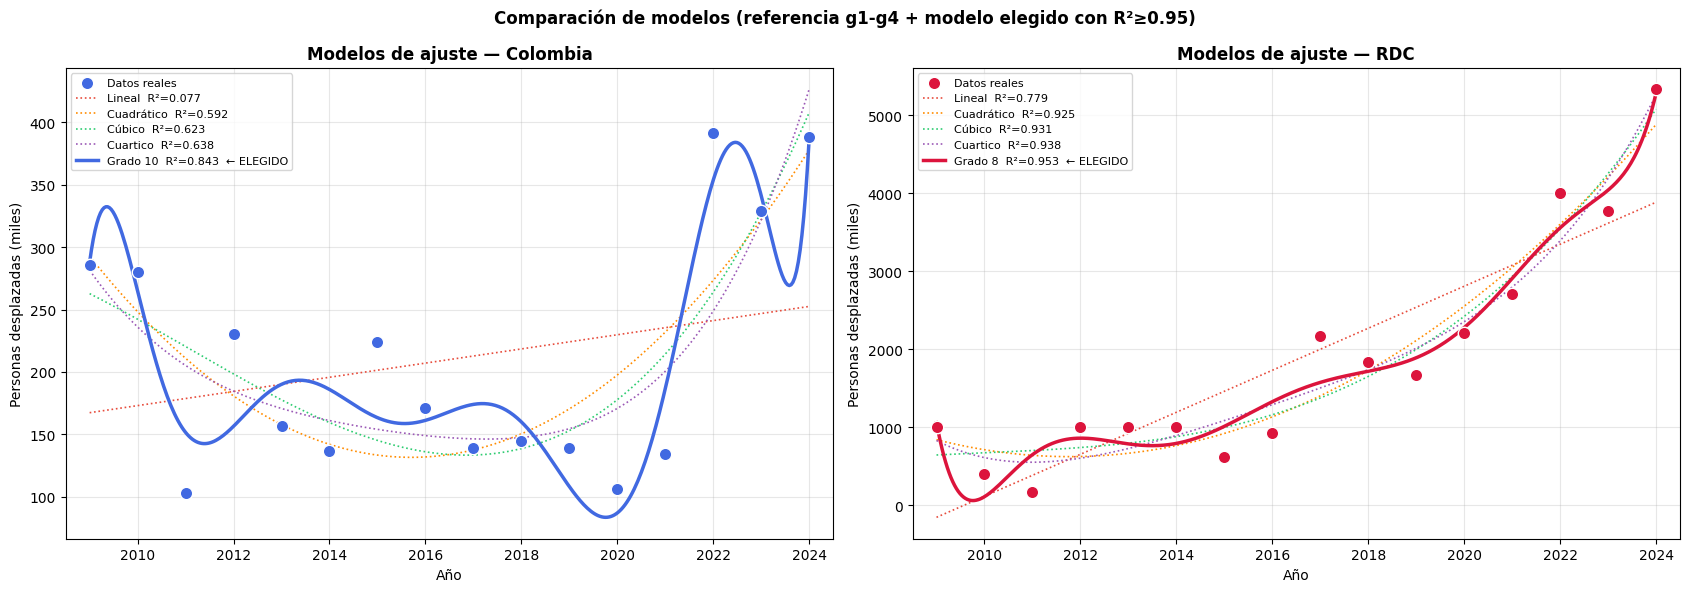

In [9]:
# ============================================================
# PASO 6: VISUALIZAR MODELOS CLAVE
# ============================================================
# Para no saturar la gráfica, mostramos solo:
#   - Grados 1, 2, 3, 4 (referencia base)
#   - El modelo elegido (mínimo grado con R²≥0.95)

t_suave     = np.linspace(0, 15, 400)
years_suave = t_suave + 2009

def get_modelo_elegido(resultados):
    """Devuelve la clave del mínimo grado con R²≥0.95, o el mejor disponible."""
    polys = {k: v for k, v in resultados.items() if v['tipo'] == 'Polinomial'}
    candidatos = {k: v for k, v in polys.items() if v['r2'] >= 0.95}
    if candidatos:
        return min(candidatos, key=lambda k: candidatos[k]['grado'])
    return max(polys, key=lambda k: polys[k]['r2'])

# Extraer datos relevantes para visualización
y_col = list_colombia
y_rdc = list_rdc
t = años_finales

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, resultados, y_datos, nombre, color_datos in [
    (axes[0], resultados_colombia, y_col, 'Colombia', 'royalblue'),
    (axes[1], resultados_rdc, y_rdc, 'RDC',      'crimson')
]:
    ax.scatter(t + 2009, y_datos/1000, color=color_datos, s=80,
               zorder=10, label='Datos reales', marker='o', edgecolors='white')

    # Grados de referencia (1-4)
    for g in range(1, 5):
        grado_nombre = GRADOS_DE_POLINOMIO[g]
        # Buscar la clave en resultados que corresponda a este grado
        clave = next((k for k, v in resultados.items() if v['grado'] == g), None)
        if clave is None:
            continue
        datos = resultados[clave]
        y_curva = np.polyval(datos['coeficientes'], t_suave)
        if y_curva.max() < 1e7 and y_curva.min() > -1e6:
            colores_base = ['#E74C3C', '#FF8C00', '#2ECC71', '#9B59B6']
            ax.plot(years_suave, y_curva/1000, color=colores_base[g-1], linewidth=1.2,
                    linestyle=':', label=f"{grado_nombre}  R²={datos['r2']:.3f}")

    # Modelo elegido (mínimo grado con R²≥0.95)
    clave_el = get_modelo_elegido(resultados)
    datos_el = resultados[clave_el]
    if datos_el['tipo'] == 'Polinomial':
        y_curva_el = np.polyval(datos_el['coeficientes'], t_suave)
        if y_curva_el.max() < 1e7 and y_curva_el.min() > -1e6:
            ax.plot(years_suave, y_curva_el/1000, color=color_datos, linewidth=2.5,
                    linestyle='-', label=f"Grado {datos_el['grado']}  R²={datos_el['r2']:.3f}  ← ELEGIDO")

    ax.set_title(f'Modelos de ajuste — {nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Personas desplazadas (miles)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2008.5, 2024.5)

plt.suptitle('Comparación de modelos (referencia g1-g4 + modelo elegido con R²≥0.95)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


  SPLINE CÚBICO — COLOMBIA
  R² = 1.000000  (siempre ≈ 1.0, no es informativo)
  Número de segmentos: 15
  Coeficientes totales: 4 × 15 = 60

  Coeficientes del PRIMER segmento (t=0→t=1, año 2009-2010):
    a (t³):     132,223.30
    b (t²):    -482,169.91
    c (t¹):     343,946.61
    d (t⁰):     286,000.00

  → Hay 15 conjuntos distintos de (a,b,c,d).
    No existe una sola ecuación para todo el rango 2009–2024.

  SPLINE CÚBICO — RDC
  R² = 1.000000  (siempre ≈ 1.0, no es informativo)
  Número de segmentos: 15
  Coeficientes totales: 4 × 15 = 60

  Coeficientes del PRIMER segmento (t=0→t=1, año 2009-2010):
    a (t³):     269,547.80
    b (t²):    -624,643.41
    c (t¹):    -244,904.39
    d (t⁰):   1,000,000.00

  → Hay 15 conjuntos distintos de (a,b,c,d).
    No existe una sola ecuación para todo el rango 2009–2024.


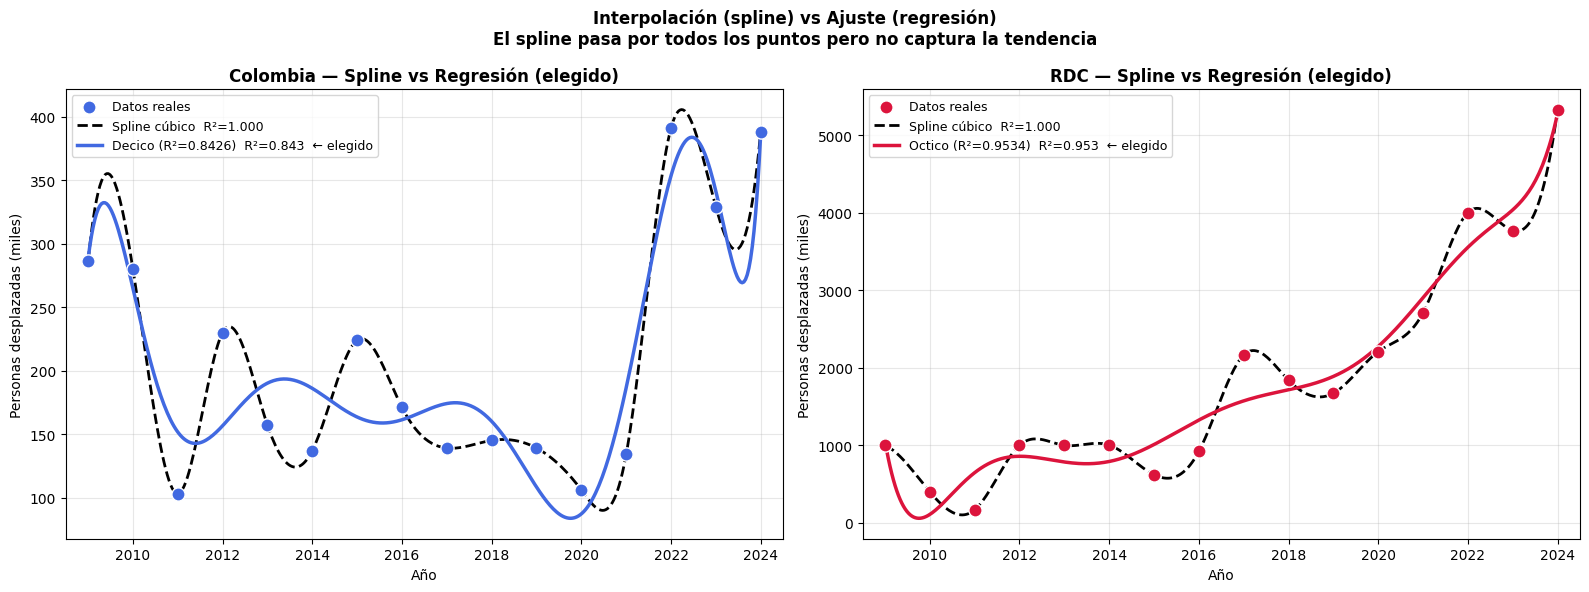

In [13]:
from scipy.interpolate import CubicSpline

def analizar_spline (t, y, nombre_pais):
    cs = CubicSpline(t, y)
    y_pred = cs(t)
    r2 = r2_score(y, y_pred)

    print(f"\n{'='*60}")
    print(f"  SPLINE CÚBICO — {nombre_pais.upper()}")
    print(f"{'='*60}")
    print(f"  R² = {r2:.6f}  (siempre ≈ 1.0, no es informativo)")
    print(f"  Número de segmentos: {len(t) - 1}")
    print(f"  Coeficientes totales: {cs.c.shape[0]} × {cs.c.shape[1]} = {cs.c.size}")
    print(f"\n  Coeficientes del PRIMER segmento (t=0→t=1, año 2009-2010):")
    print(f"    a (t³): {cs.c[0, 0]:>14,.2f}")
    print(f"    b (t²): {cs.c[1, 0]:>14,.2f}")
    print(f"    c (t¹): {cs.c[2, 0]:>14,.2f}")
    print(f"    d (t⁰): {cs.c[3, 0]:>14,.2f}")
    print(f"\n  → Hay {len(t)-1} conjuntos distintos de (a,b,c,d).")
    print(f"    No existe una sola ecuación para todo el rango 2009–2024.")
    return cs

cs_col = analizar_spline(t, y_col, 'Colombia')
cs_rdc = analizar_spline(t, y_rdc, 'RDC')

# ── Visualización: spline vs modelo elegido (R²≥0.95) ────────────────────────
t_suave  = np.linspace(0, 15, 400)
years_s  = t_suave + 2009

clave_col_el = get_modelo_elegido(resultados_colombia)
clave_rdc_el = get_modelo_elegido(resultados_rdc)
coefs_col_el = resultados_colombia[clave_col_el]['coeficientes']
coefs_rdc_el = resultados_rdc[clave_rdc_el]['coeficientes']
r2_col_el    = resultados_colombia[clave_col_el]['r2']
r2_rdc_el    = resultados_rdc[clave_rdc_el]['r2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cs, coefs_el, clave_el, r2_el, y_datos, nombre, color in [
    (axes[0], cs_col, coefs_col_el, clave_col_el, r2_col_el, y_col, 'Colombia', 'royalblue'),
    (axes[1], cs_rdc, coefs_rdc_el, clave_rdc_el, r2_rdc_el, y_rdc, 'RDC',      'crimson'),
]:
    ax.scatter(t + 2009, y_datos/1000, color=color, s=90, zorder=10,
               label='Datos reales', marker='o', edgecolors='white')
    ax.plot(years_s, cs(t_suave)/1000, color='black', linewidth=2, linestyle='--',
            label='Spline cúbico  R²=1.000')
    ax.plot(years_s, np.polyval(coefs_el, t_suave)/1000, color=color, linewidth=2.5,
            label=f'{clave_el}  R²={r2_el:.3f}  ← elegido')

    ax.set_title(f'{nombre} — Spline vs Regresión (elegido)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Personas desplazadas (miles)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2008.5, 2024.5)

plt.suptitle('Interpolación (spline) vs Ajuste (regresión)\n'
             'El spline pasa por todos los puntos pero no captura la tendencia',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()




  COEFICIENTES DEL SPLINE CÚBICO — COLOMBIA
  S_i(t) = a(t-t_i)³ + b(t-t_i)² + c(t-t_i) + d   (centrado en t_i)
  Segmento  Rango años             a (t³)         b (t²)         c (t¹)         d (t⁰)
  ------------------------------------------------------------------------------------
  i=0       2009-2010          132,223.30    -482,169.91     343,946.61     286,000.00
  i=1       2010-2011          132,223.30     -85,500.00    -223,723.30     280,000.00
  i=2       2011-2012         -186,116.52     311,169.91       1,946.61     103,000.00
  i=3       2012-2013          108,242.76    -247,179.64      65,936.88     230,000.00
  i=4       2013-2014            6,145.48      77,548.64    -103,694.12     157,000.00
  i=5       2014-2015          -78,824.70      95,985.09      69,839.61     137,000.00
  i=6       2015-2016           62,153.30    -140,489.00      25,335.70     224,000.00
  i=7       2016-2017           -8,788.52      45,970.91     -69,182.39     171,000.00
  i=8       2017-

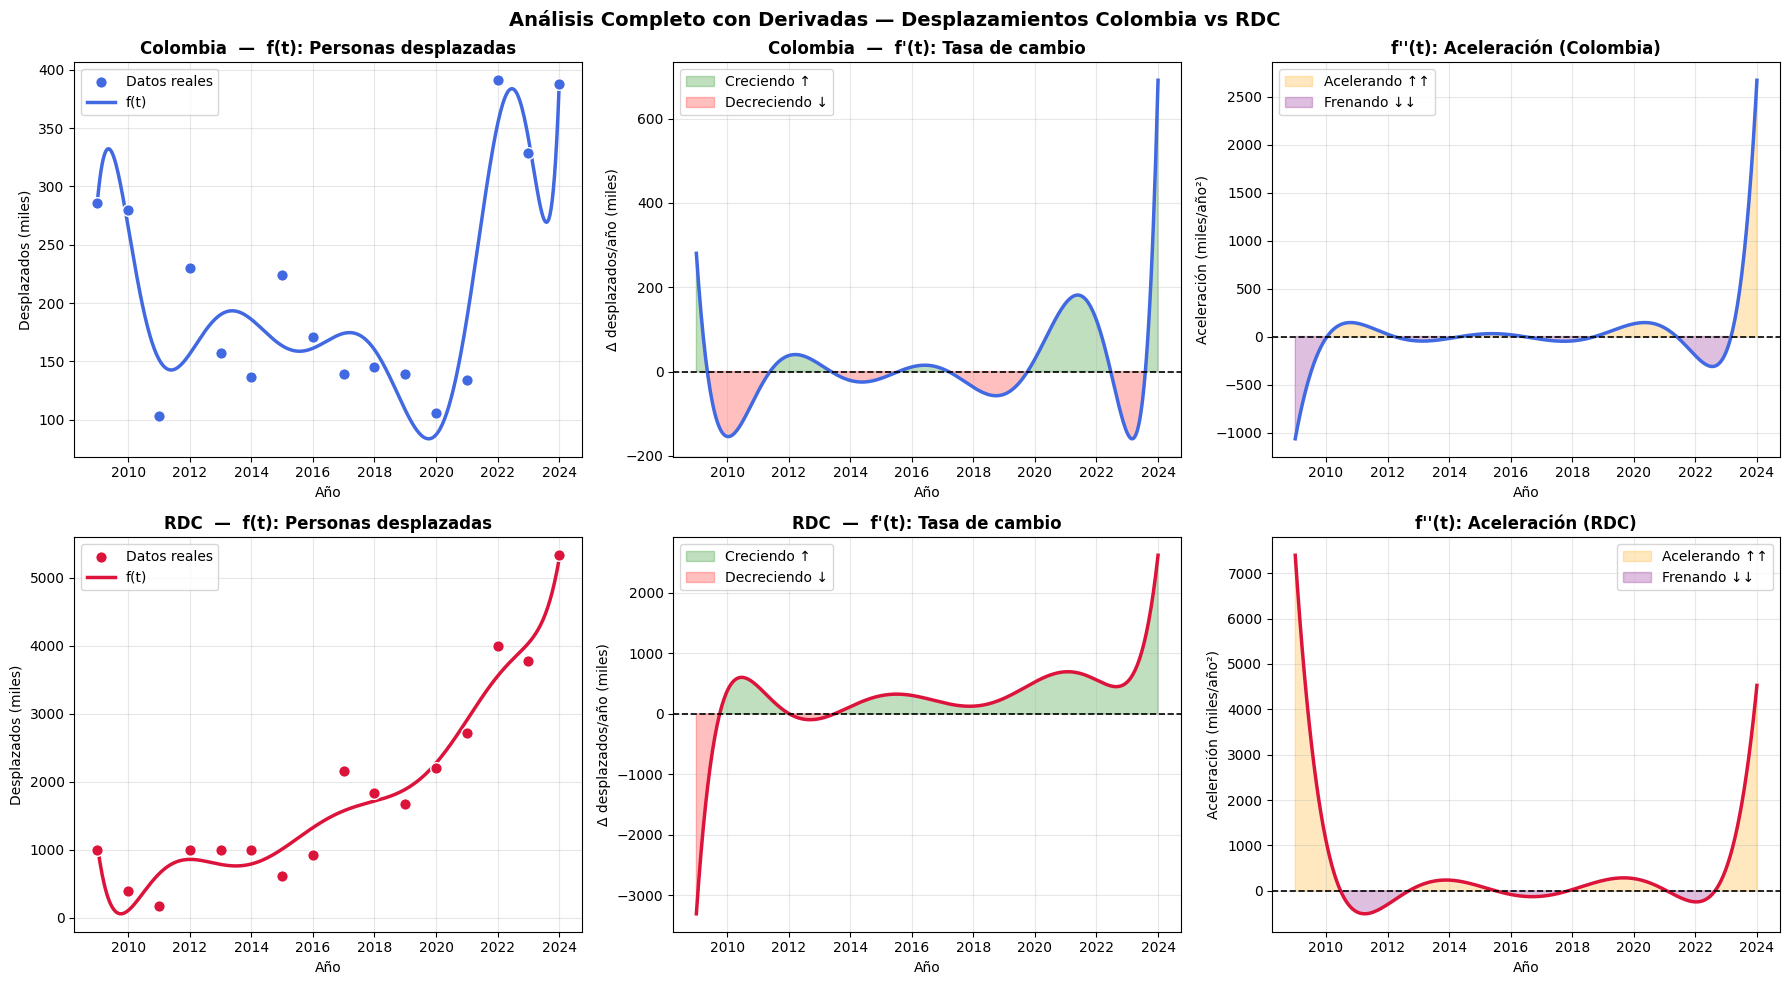

In [ ]:
# ============================================================
# PASO 6c: COEFICIENTES DE CADA SEGMENTO DEL SPLINE CÚBICO
# ============================================================
# Cada segmento i del spline es:
#   S_i(t) = a*(t - t_i)³ + b*(t - t_i)² + c*(t - t_i) + d
# centrado en el nodo izquierdo t_i (no en t=0).
#
# cs.c tiene forma (4, 15): 4 coeficientes × 15 segmentos.
#   cs.c[0, i] = a   cs.c[1, i] = b   cs.c[2, i] = c   cs.c[3, i] = d
# Nota: d = y_i siempre (valor del dato en el nodo izquierdo).

def imprimir_coefs_spline(cs, t, nombre_pais, year0=2009):
    print(f"\n{'='*82}")
    print(f"  COEFICIENTES DEL SPLINE CÚBICO — {nombre_pais.upper()}")
    print(f"  S_i(t) = a(t-t_i)³ + b(t-t_i)² + c(t-t_i) + d   (centrado en t_i)")
    print(f"{'='*82}")
    print(f"  {'Segmento':<10}{'Rango años':<14}"
          f"{'a (t³)':>15}{'b (t²)':>15}{'c (t¹)':>15}{'d (t⁰)':>15}")
    print(f"  {'-'*10}{'-'*14}{'-'*15}{'-'*15}{'-'*15}{'-'*15}")
    for i in range(len(t) - 1):
        a, b, c, d = cs.c[:, i]
        rango = f"{int(year0+t[i])}-{int(year0+t[i+1])}"
        print(f"  i={i:<8}{rango:<14}{a:>15,.2f}{b:>15,.2f}{c:>15,.2f}{d:>15,.2f}")

imprimir_coefs_spline(cs_col, t, 'Colombia')
imprimir_coefs_spline(cs_rdc, t, 'RDC')

# ── También como DataFrame (útil para exportar o manipular) ─────────────────
def coefs_a_dataframe(cs, t, year0=2009):
    return pd.DataFrame({
        'segmento':     range(len(t) - 1),
        'año_inicio':   (year0 + t[:-1]).astype(int),   #-1 en vectores es la ultima posición
        'año_fin':      (year0 + t[1:]).astype(int),
        't_i (centro)': t[:-1],
        'a (t³)':       cs.c[0],
        'b (t²)':       cs.c[1],
        'c (t¹)':       cs.c[2],
        'd (t⁰)':       cs.c[3],
    })

df_coefs_col = coefs_a_dataframe(cs_col, t)
df_coefs_rdc = coefs_a_dataframe(cs_rdc, t)

print("\n\nDataFrame — Colombia:")
print(df_coefs_col.to_string(index=False))
print("\nDataFrame — RDC:")
print(df_coefs_rdc.to_string(index=False))

# Para exportar a CSV si lo necesitas:
# df_coefs_col.to_csv('spline_coefs_colombia.csv', index=False)
# df_coefs_rdc.to_csv('spline_coefs_rdc.csv', index=False)

# ============================================================
# PASO 7: SELECCIONAR EL MEJOR MODELO Y CALCULAR DERIVADAS
# ============================================================
# Criterio: mínimo grado con R² ≥ 0.95.
# Si ningún grado lo alcanza, se toma el de mayor R².
# np.polyder funciona con cualquier grado polinómico.

def seleccionar_mejor_poly(resultados, umbral=0.95):
    """Devuelve (nombre, coefs, r2) del mínimo grado con R²≥umbral, o el mejor."""
    polys = {
        k: v for k, v in resultados.items()
        if str(v.get('tipo', '')).lower().startswith('pol')
    }
    candidatos = {k: v for k, v in polys.items() if v['r2'] >= umbral}
    if candidatos:
        mejor_nombre = min(candidatos, key=lambda k: candidatos[k]['grado'])
    else:
        mejor_nombre = max(polys, key=lambda k: polys[k]['r2'])
    return mejor_nombre, polys[mejor_nombre]['coeficientes'], polys[mejor_nombre]['r2']


def analisis_derivadas(t, y, nombre_pais, resultados):
    nombre_mejor, coefs, r2 = seleccionar_mejor_poly(resultados)

    print(f"\n{'='*65}")
    print(f"  ANÁLISIS DE DERIVADAS — {nombre_pais.upper()}")
    print(f"  Modelo: {nombre_mejor}  |  R² = {r2:.4f}")    #.4f para mostrar 4 decimales
    print(f"{'='*65}")

    d1_coefs = np.polyder(coefs)      # f'(t)
    d2_coefs = np.polyder(coefs, 2)   # f''(t)

    print(f"\nf(t)   grado {len(coefs)-1}, coeficientes (mayor a menor potencia):")
    print(f"  {[f'{c:.2f}' for c in coefs]}")
    print(f"f'(t)  coeficientes: {[f'{c:.2f}' for c in d1_coefs]}")
    print(f"f''(t) coeficientes: {[f'{c:.2f}' for c in d2_coefs]}")

    # ── Puntos críticos: raíces de f'(t) ────────────────────────────────
    raices_d1 = np.roots(d1_coefs)
    criticos  = raices_d1[
        np.isreal(raices_d1) & (raices_d1.real >= 0) & (raices_d1.real <= 15)
    ].real

    print(f"\n  PUNTOS CRÍTICOS (donde f'(t) = 0):")
    if len(criticos) > 0:
        for tc in sorted(criticos):
            anio   = tc + 2009
            valor  = np.polyval(coefs, tc) / 1000
            d2_val = np.polyval(d2_coefs, tc)
            tipo   = "MÁXIMO LOCAL" if d2_val < 0 else "MÍNIMO LOCAL"
            print(f"    t={tc:5.2f} → año ≈ {anio:7.1f} | {valor:>7.1f}k desplazados | {tipo}")     #5.2f para mostrar 2 decimales en t, 7.1f para mostrar el valor con 1 decimal y alineado a la derecha
    else:
        print("    No hay puntos críticos en 2009–2024")

    # ── Puntos de inflexión: raíces de f''(t) ───────────────────────────
    raices_d2   = np.roots(d2_coefs)
    inflexiones = raices_d2[
        np.isreal(raices_d2) & (raices_d2.real >= 0) & (raices_d2.real <= 15)
    ].real

    print(f"\n  PUNTOS DE INFLEXIÓN (donde f''(t) = 0):")
    if len(inflexiones) > 0:
        for ti in sorted(inflexiones):
            anio  = ti + 2009
            valor = np.polyval(coefs, ti) / 1000
            d2_antes  = np.polyval(d2_coefs, ti - 0.5)
            d2_despues = np.polyval(d2_coefs, ti + 0.5)
            if d2_antes < 0 and d2_despues > 0:
                desc = "la crisis empieza a ACELERAR"
            elif d2_antes > 0 and d2_despues < 0:
                desc = "la crisis empieza a DESACELERAR"
            else:
                desc = "cambio de curvatura"
            print(f"    t={ti:5.2f} → año ≈ {anio:7.1f} | {valor:>7.1f}k desplazados | {desc}")
    else:
        print("    No hay puntos de inflexión en 2009–2024")

    tasa_final = np.polyval(d1_coefs, 15)
    print(f"\n  TASA DE CAMBIO en 2024: {tasa_final/1000:+.1f}k personas/año")
    tendencia = "AUMENTANDO" if tasa_final > 0 else "DISMINUYENDO"
    print(f"  → El desplazamiento está {tendencia}")

    return coefs, d1_coefs, d2_coefs


coefs_col, d1_col, d2_col = analisis_derivadas(t, y_col, 'Colombia', resultados_colombia)
coefs_rdc, d1_rdc, d2_rdc = analisis_derivadas(t, y_rdc, 'RDC',      resultados_rdc)


# ============================================================
# PASO 8: VISUALIZACIÓN COMPLETA — f(t), f'(t) y f''(t)
# ============================================================
# Cada fila = un país. Cada columna = función, derivada, segunda derivada.
# Las zonas coloreadas en f'(t) muestran cuándo crece vs decrece.
# Las zonas coloreadas en f''(t) muestran cuándo la crisis acelera vs frena.

t_suave    = np.linspace(0, 15, 400)
years_s    = t_suave + 2009

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (coefs_col, d1_col, d2_col, y_col, 'Colombia', 'royalblue'),
    (coefs_rdc, d1_rdc, d2_rdc, y_rdc, 'RDC',      'crimson'),
]

for fila, (coefs, d1, d2, y_datos, nombre, color) in enumerate(datasets):

    f_suave  = np.polyval(coefs, t_suave)
    d1_suave = np.polyval(d1,    t_suave)
    d2_suave = np.polyval(d2,    t_suave)

    # ── Columna 0: f(t) — el modelo ajustado ──────────────────────────
    ax = axes[fila][0]
    ax.scatter(t + 2009, y_datos/1000, color=color, s=70, zorder=5,
               label='Datos reales', edgecolors='white')
    ax.plot(years_s, f_suave/1000, color=color, linewidth=2.5, label='f(t)')
    ax.set_title(f'{nombre}  —  f(t): Personas desplazadas', fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Desplazados (miles)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Columna 1: f'(t) — tasa de cambio ────────────────────────────
    ax = axes[fila][1]
    ax.plot(years_s, d1_suave/1000, color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.fill_between(years_s, d1_suave/1000, 0,
                    where=(d1_suave > 0), alpha=0.25, color='green', label='Creciendo ↑')
    ax.fill_between(years_s, d1_suave/1000, 0,
                    where=(d1_suave < 0), alpha=0.25, color='red',   label='Decreciendo ↓')
    ax.set_title(f"{nombre}  —  f'(t): Tasa de cambio", fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Δ desplazados/año (miles)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Columna 2: f''(t) — aceleración ──────────────────────────────
    ax = axes[fila][2]
    ax.plot(years_s, d2_suave/1000, color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.fill_between(years_s, d2_suave/1000, 0,
                    where=(d2_suave > 0), alpha=0.25, color='orange', label='Acelerando ↑↑')
    ax.fill_between(years_s, d2_suave/1000, 0,
                    where=(d2_suave < 0), alpha=0.25, color='purple', label='Frenando ↓↓')
    ax.set_title(f"f''(t): Aceleración ({nombre})", fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Aceleración (miles/año²)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Análisis Completo con Derivadas — Desplazamientos Colombia vs RDC',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()